# Confidence Intervals (CI)

## Definition

A confidence interval is a range of plausible values for a population parameter estimated from a sample.

Example:

Mean = 62,231

95% CI = [60,900, 63,500]

---

## Purpose

Instead of giving one estimate (point estimate), provide a range that reflects sampling uncertainty.

---

## Confidence Levels

- 90%
- 95%
- 99%

Higher confidence ⇒ Wider interval.

---

## Correct Interpretation

A 95% confidence interval means:

If we repeatedly take samples and construct confidence intervals the same way, about 95% of those intervals will contain the true population parameter.

It **does not** mean there is a 95% probability that the true value lies in the computed interval.

---

## Bootstrap Confidence Interval

1. Draw bootstrap samples.
2. Compute the statistic for each sample.
3. Repeat many times.
4. Sort the bootstrap statistics.
5. Trim the lower and upper tails.
6. Remaining endpoints form the confidence interval.

---

## Factors Affecting Width

- Larger sample size → Narrower interval
- Higher confidence level → Wider interval
- Larger standard error → Wider interval

---

## Formula Connection

$$
SE=\frac{s}{\sqrt n}
$$

Confidence Interval ≈

$$
\text{Estimate} \pm \text{Margin of Error}
$$

Margin of Error depends on the Standard Error.

---

## Learning Flow

Population → Sample → Sampling Distribution → Standard Error → Bootstrap → Confidence Interval

In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

np.random.seed(42)

In [7]:
data = np.random.normal(10, 3, size= 10000)

In [8]:
data.mean()

np.float64(9.962611693307952)

In [9]:
sample = np.random.choice(data, size = 100, replace=False)

In [10]:
sample.mean()

np.float64(10.128003816869809)

In [11]:
def bootstrap_means(sample, n_bootstrap):
    means = []

    for _ in range(n_bootstrap):
        temp = np.random.choice(
            sample,
            size = len(sample),
            replace=True
        )
        means.append(temp.mean())
    return means

In [29]:
m_sample = bootstrap_means(sample, 500) # Sample of bootstrap mean's of the original sample

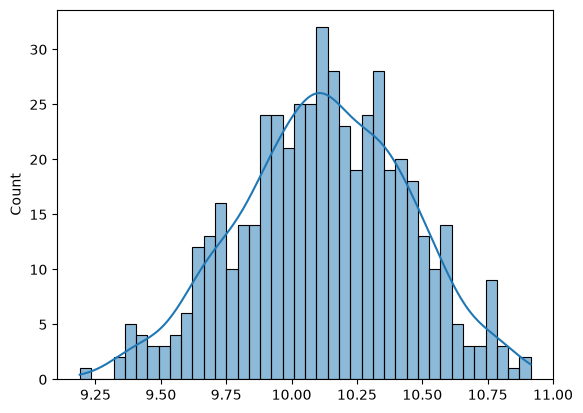

In [30]:
sns.histplot(
    m_sample,
    bins = 40,
    kde = True
)

plt.show()

In [35]:
# Calculating 95% interval
lower = np.percentile(m_sample, 2.5)
higher = np.percentile(m_sample, 97.5)

print(f"We have 95% confidence that the true mean lies between {lower} to {higher}")

We have 95% confidence that the true mean lies between 9.45577260943612 to 10.75088897336999


In [32]:
# Calculating 90% interval
lower = np.percentile(m_sample, 5)
higher = np.percentile(m_sample, 95)

print(f"We have 90% confidence that the true mean lies between {lower} to {higher}")

We have 90% confidence that the true mean lies between 9.59500587641777 to 10.622532060131581


In [33]:
# Calculating 99% interval
lower = np.percentile(m_sample, 0.5)
higher = np.percentile(m_sample, 99.5)

print(f"We have 99% confidence that the true mean lies between {lower} to {higher}")

We have 99% confidence that the true mean lies between 9.36104543629594 to 10.836932159771964


# Visualising the confidence interval

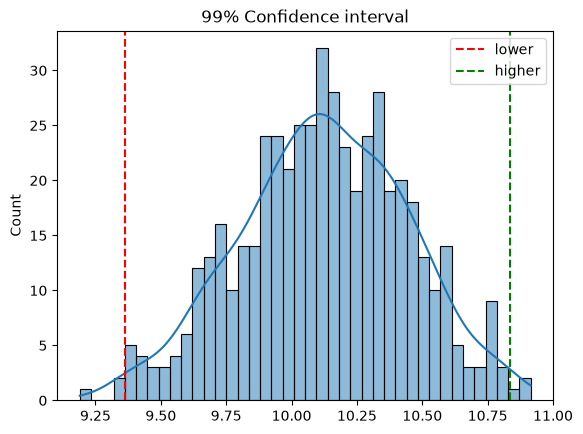

In [34]:
sns.histplot(
    m_sample,
    bins = 40,
    kde = True
)
plt.axvline(lower, linestyle= "--", color="red", label = "lower")
plt.axvline(higher,linestyle= "--", color="Green", label = "higher")
plt.title("99% Confidence interval")
plt.legend()

plt.show()

In [39]:
boolean = (m_sample < higher) & (m_sample > lower) 
print(boolean[:100])

[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True False  True  True  True  True
  True  True  True  True  True False False  True  True  True  True  True
  True  True  True  True  True  True  True False  True  True  True  True
 False  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True False  True  True
  True False  True  True]
